# EDA 05.04 — Weather, Correlation, and Missingness

All calculations use `master_dataset_clean.parquet`. The source dataset is not modified.

In [1]:
# Import libraries
from pathlib import Path
import sys
from IPython.display import Image, display

In [2]:
# define the root directory of the project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'eda.yaml'
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/eda.yaml')

In [3]:
# Import module to manage the EDA process
from src.ontario_peak_risk.eda.common import (
    load_eda_config,
    prepare_output_directories,
    load_clean_dataset,
)

In [4]:
# Config EDA process and Load the dataset
CONFIG, _ = load_eda_config(CONFIG_PATH)
REPORTS_DIR, FIGURES_DIR, DOCS_DIR = prepare_output_directories(CONFIG, PROJECT_ROOT)
dataset = load_clean_dataset(CONFIG, PROJECT_ROOT)
TARGET = CONFIG['columns']['target']

dataset.shape

(262944, 66)

In [5]:
# Import the function to run the weather missingness analysis
from src.ontario_peak_risk.eda.weather_missing import run_weather_missing

In [6]:
# Generate the weather missingness analysis of the dataset and save the results in the output directories
results = run_weather_missing(
    dataset,
    TARGET,
    CONFIG['columns']['core_weather'],
    CONFIG['analysis']['high_missingness_threshold_pct'],
    CONFIG['analysis']['minimum_weather_coverage_pct'],
    REPORTS_DIR,
    FIGURES_DIR,
    DOCS_DIR,
)

print("Weather missingness analysis completed.")


Weather missingness analysis completed.


In [7]:
# Show results of the weather missingness analysis
results['correlations']

,weather_variable,pairwise_rows,coverage_pct,pearson_correlation,pearson_strength,spearman_correlation,spearman_strength
0,Hmdx,46290,17.604509,0.378096,weak,0.314041,weak
1,Wind Spd (km/h),131454,49.993154,0.111686,very weak,0.121575,very weak
2,Stn Press (kPa),262803,99.946376,-0.109696,very weak,-0.112676,very weak
3,Rel Hum (%),262800,99.945235,-0.105441,very weak,-0.099466,very weak
4,Wind Chill,26346,10.019624,-0.073274,very weak,-0.080263,very weak
5,Temp (°C),262803,99.946376,0.080931,very weak,0.032229,very weak
6,Wind Dir (10s deg),129276,49.164841,-0.019786,very weak,-0.030036,very weak
7,Visibility (km),131451,49.992014,0.002785,very weak,-0.014348,very weak
8,Precip. Amount (mm),131349,49.953222,0.002963,very weak,0.012151,very weak
9,Dew Point Temp (°C),262800,99.945235,0.038860,very weak,-0.003568,very weak


In [8]:
# Display weather-variable coverage by station
results["coverage"]

,assigned_climate_id,assigned_station_name,column,rows,non_null_count,missing_count,coverage_pct
0,6158355,TORONTO CITY,Temp (°C),131472,131349,123,99.906444
1,6158355,TORONTO CITY,Dew Point Temp (°C),131472,131349,123,99.906444
2,6158355,TORONTO CITY,Rel Hum (%),131472,131349,123,99.906444
3,6158355,TORONTO CITY,Stn Press (kPa),131472,131349,123,99.906444
4,6158355,TORONTO CITY,Wind Spd (km/h),131472,0,131472,0.000000
5,6158355,TORONTO CITY,Precip. Amount (mm),131472,131349,123,99.906444
6,6158355,TORONTO CITY,Visibility (km),131472,0,131472,0.000000
7,6158355,TORONTO CITY,Wind Dir (10s deg),131472,0,131472,0.000000
8,6158355,TORONTO CITY,Hmdx,131472,23292,108180,17.716320
9,6158355,TORONTO CITY,Wind Chill,131472,0,131472,0.000000


In [9]:
# Display weather coverage by FSA and year
results["coverage_period"]

,fsa,year,column,coverage_pct
0,L4T,2021,Temp (°C),99.977169
1,L4T,2021,Dew Point Temp (°C),99.965753
2,L4T,2021,Rel Hum (%),99.965753
3,L4T,2021,Stn Press (kPa),99.977169
4,L4T,2021,Wind Spd (km/h),99.977169
...,...,...,...,...
295,M9W,2025,Precip. Amount (mm),0.000000
296,M9W,2025,Visibility (km),99.988584
297,M9W,2025,Wind Dir (10s deg),98.173516
298,M9W,2025,Hmdx,17.442922


In [10]:
# Display temperature coverage by FSA and year
results["coverage_period"].query(
    "column == 'Temp (°C)'"
)

,fsa,year,column,coverage_pct
0,L4T,2021,Temp (°C),99.977169
10,L4T,2022,Temp (°C),99.988584
20,L4T,2023,Temp (°C),99.988584
30,L4T,2024,Temp (°C),99.988616
40,L4T,2025,Temp (°C),99.988584
50,M5R,2021,Temp (°C),99.920091
60,M5R,2022,Temp (°C),99.942922
70,M5R,2023,Temp (°C),99.931507
80,M5R,2024,Temp (°C),99.920310
90,M5R,2025,Temp (°C),99.817352


In [11]:
# Display correlations between weather variables and electricity demand
results["correlations"]

,weather_variable,pairwise_rows,coverage_pct,pearson_correlation,pearson_strength,spearman_correlation,spearman_strength
0,Hmdx,46290,17.604509,0.378096,weak,0.314041,weak
1,Wind Spd (km/h),131454,49.993154,0.111686,very weak,0.121575,very weak
2,Stn Press (kPa),262803,99.946376,-0.109696,very weak,-0.112676,very weak
3,Rel Hum (%),262800,99.945235,-0.105441,very weak,-0.099466,very weak
4,Wind Chill,26346,10.019624,-0.073274,very weak,-0.080263,very weak
5,Temp (°C),262803,99.946376,0.080931,very weak,0.032229,very weak
6,Wind Dir (10s deg),129276,49.164841,-0.019786,very weak,-0.030036,very weak
7,Visibility (km),131451,49.992014,0.002785,very weak,-0.014348,very weak
8,Precip. Amount (mm),131349,49.953222,0.002963,very weak,0.012151,very weak
9,Dew Point Temp (°C),262800,99.945235,0.038860,very weak,-0.003568,very weak


In [12]:
# Display electricity demand by temperature band
results["temperature_bands"]

,temperature_band,count,mean,median,maximum
0,Below -10,5055,10017.948467,9911.80,20741.6
1,-10 to 0,43314,9628.846687,9376.50,20662.3
2,0 to 10,82659,8204.396541,7714.50,18769.0
3,10 to 20,74670,7176.641784,6657.90,20451.4
4,20 to 30,55308,10796.946708,10097.65,30500.3
5,Above 30,1797,17760.429048,17578.70,33712.2


In [13]:
# Display preliminary weather-variable retention recommendations
results["retention_review"]

,column,mean_coverage_pct,spearman_correlation,spearman_strength,eda_recommendation
0,Dew Point Temp (°C),99.945235,-0.003568,very weak,retain_pending_multivariate_review
1,Hmdx,17.604509,0.314041,weak,review_for_exclusion_low_coverage
2,Precip. Amount (mm),49.953222,0.012151,very weak,retain_for_eda_review_before_modeling
3,Rel Hum (%),99.945235,-0.099466,very weak,retain_pending_multivariate_review
4,Stn Press (kPa),99.946376,-0.112676,very weak,retain_pending_multivariate_review
5,Temp (°C),99.946376,0.032229,very weak,retain_pending_multivariate_review
6,Visibility (km),49.992013,-0.014348,very weak,retain_for_eda_review_before_modeling
7,Wind Chill,10.019624,-0.080263,very weak,review_for_exclusion_low_coverage
8,Wind Dir (10s deg),49.164841,-0.030036,very weak,retain_for_eda_review_before_modeling
9,Wind Spd (km/h),49.993155,0.121575,very weak,retain_for_eda_review_before_modeling


In [14]:
# Display the correlation matrix
results["correlation_matrix"].round(3)

,total_consumption_kwh,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Stn Press (kPa),Wind Spd (km/h),Precip. Amount (mm),Visibility (km),Wind Dir (10s deg),Hmdx,Wind Chill
total_consumption_kwh,1.000,0.081,0.039,-0.105,-0.110,0.112,0.003,0.003,-0.020,0.378,-0.073
Temp (°C),0.081,1.000,0.920,-0.167,-0.113,-0.141,0.003,0.146,-0.088,0.799,0.932
Dew Point Temp (°C),0.039,0.920,1.000,0.226,-0.220,-0.223,0.073,-0.010,-0.118,0.628,0.849
Rel Hum (%),-0.105,-0.167,0.226,1.000,-0.299,-0.208,0.215,-0.462,-0.091,-0.023,0.289
Stn Press (kPa),-0.110,-0.113,-0.220,-0.299,1.000,-0.272,-0.142,0.233,-0.071,-0.118,-0.142
Wind Spd (km/h),0.112,-0.141,-0.223,-0.208,-0.272,1.000,NaN,0.044,0.314,0.188,-0.336
Precip. Amount (mm),0.003,0.003,0.073,0.215,-0.142,NaN,1.000,NaN,NaN,-0.000,NaN
Visibility (km),0.003,0.146,-0.010,-0.462,0.233,0.044,NaN,1.000,0.166,-0.029,-0.084
Wind Dir (10s deg),-0.020,-0.088,-0.118,-0.091,-0.071,0.314,NaN,0.166,1.000,0.074,-0.162
Hmdx,0.378,0.799,0.628,-0.023,-0.118,0.188,-0.000,-0.029,0.074,1.000,NaN


In [15]:
# Display the strongest overlapping missingness patterns
(
    results["overlap"]
    .query("variable_1 != variable_2")
    .sort_values(
        "both_missing_pct",
        ascending=False,
    )
    .head(15)
)

,variable_1,variable_2,both_missing_count,both_missing_pct
98,Wind Chill,Hmdx,190308,72.375867
89,Hmdx,Wind Chill,190308,72.375867
79,Wind Dir (10s deg),Wind Chill,133668,50.835159
97,Wind Chill,Wind Dir (10s deg),133668,50.835159
96,Wind Chill,Visibility (km),131493,50.007986
69,Visibility (km),Wind Chill,131493,50.007986
47,Wind Spd (km/h),Wind Dir (10s deg),131490,50.006846
46,Wind Spd (km/h),Visibility (km),131490,50.006846
67,Visibility (km),Wind Dir (10s deg),131490,50.006846
64,Visibility (km),Wind Spd (km/h),131490,50.006846


## Summary
Review the generated CSV tables, figures, and Markdown section report.

Review: 
- Report under `docs/eda/05_04_Weather_Correlation_and_Missingness.md`.
- CSV reports under `reports/eda/`.

Generated figures: 7

05_04_consumption_by_temperature_band.png


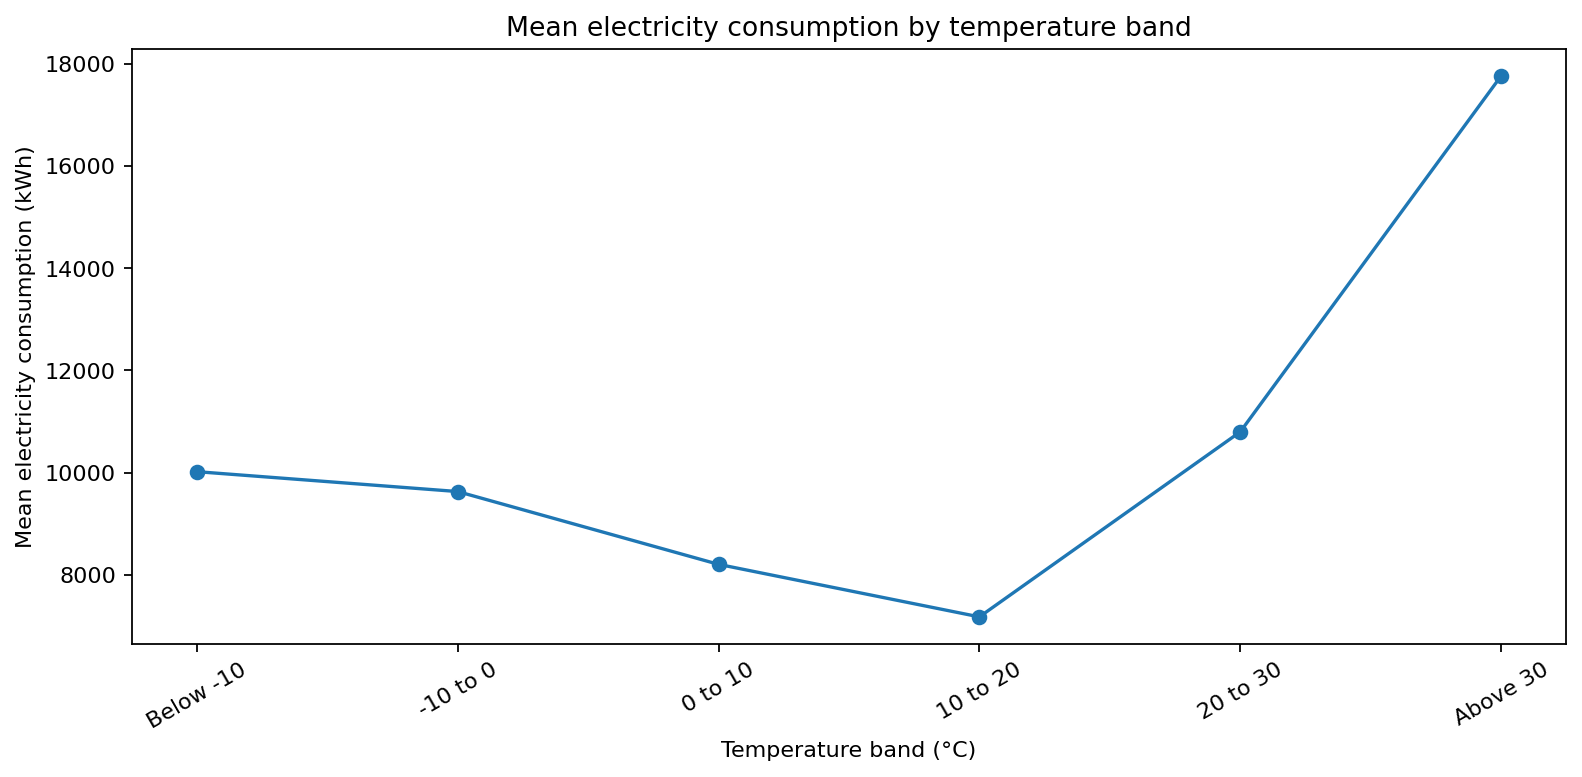


05_04_consumption_vs_temperature.png


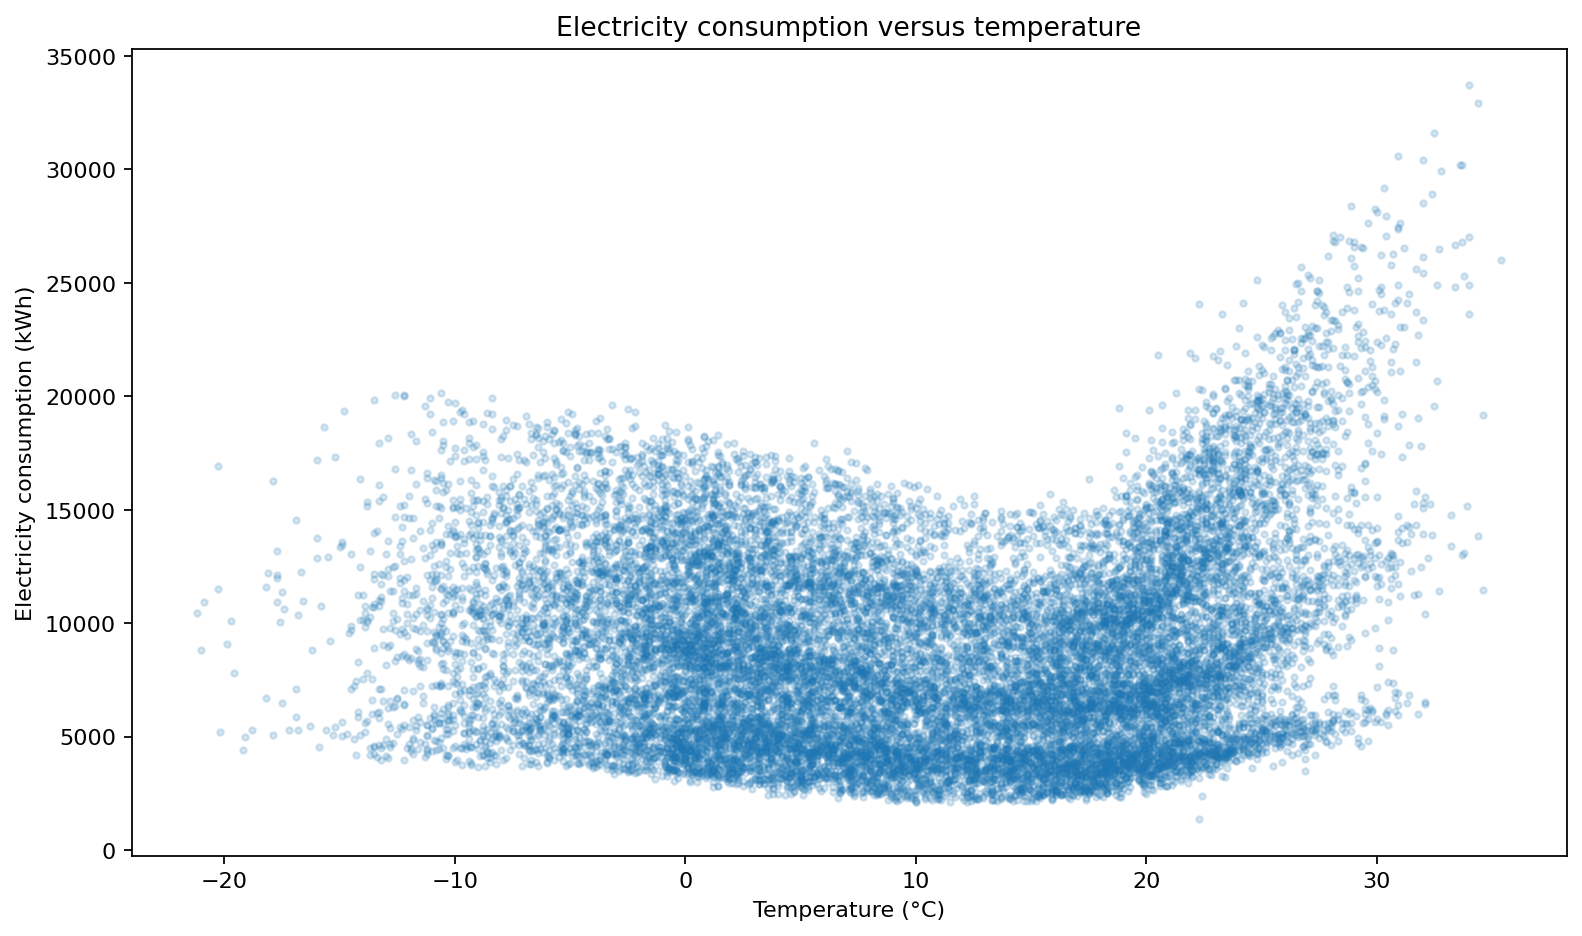


05_04_consumption_vs_temperature_enhanced.png


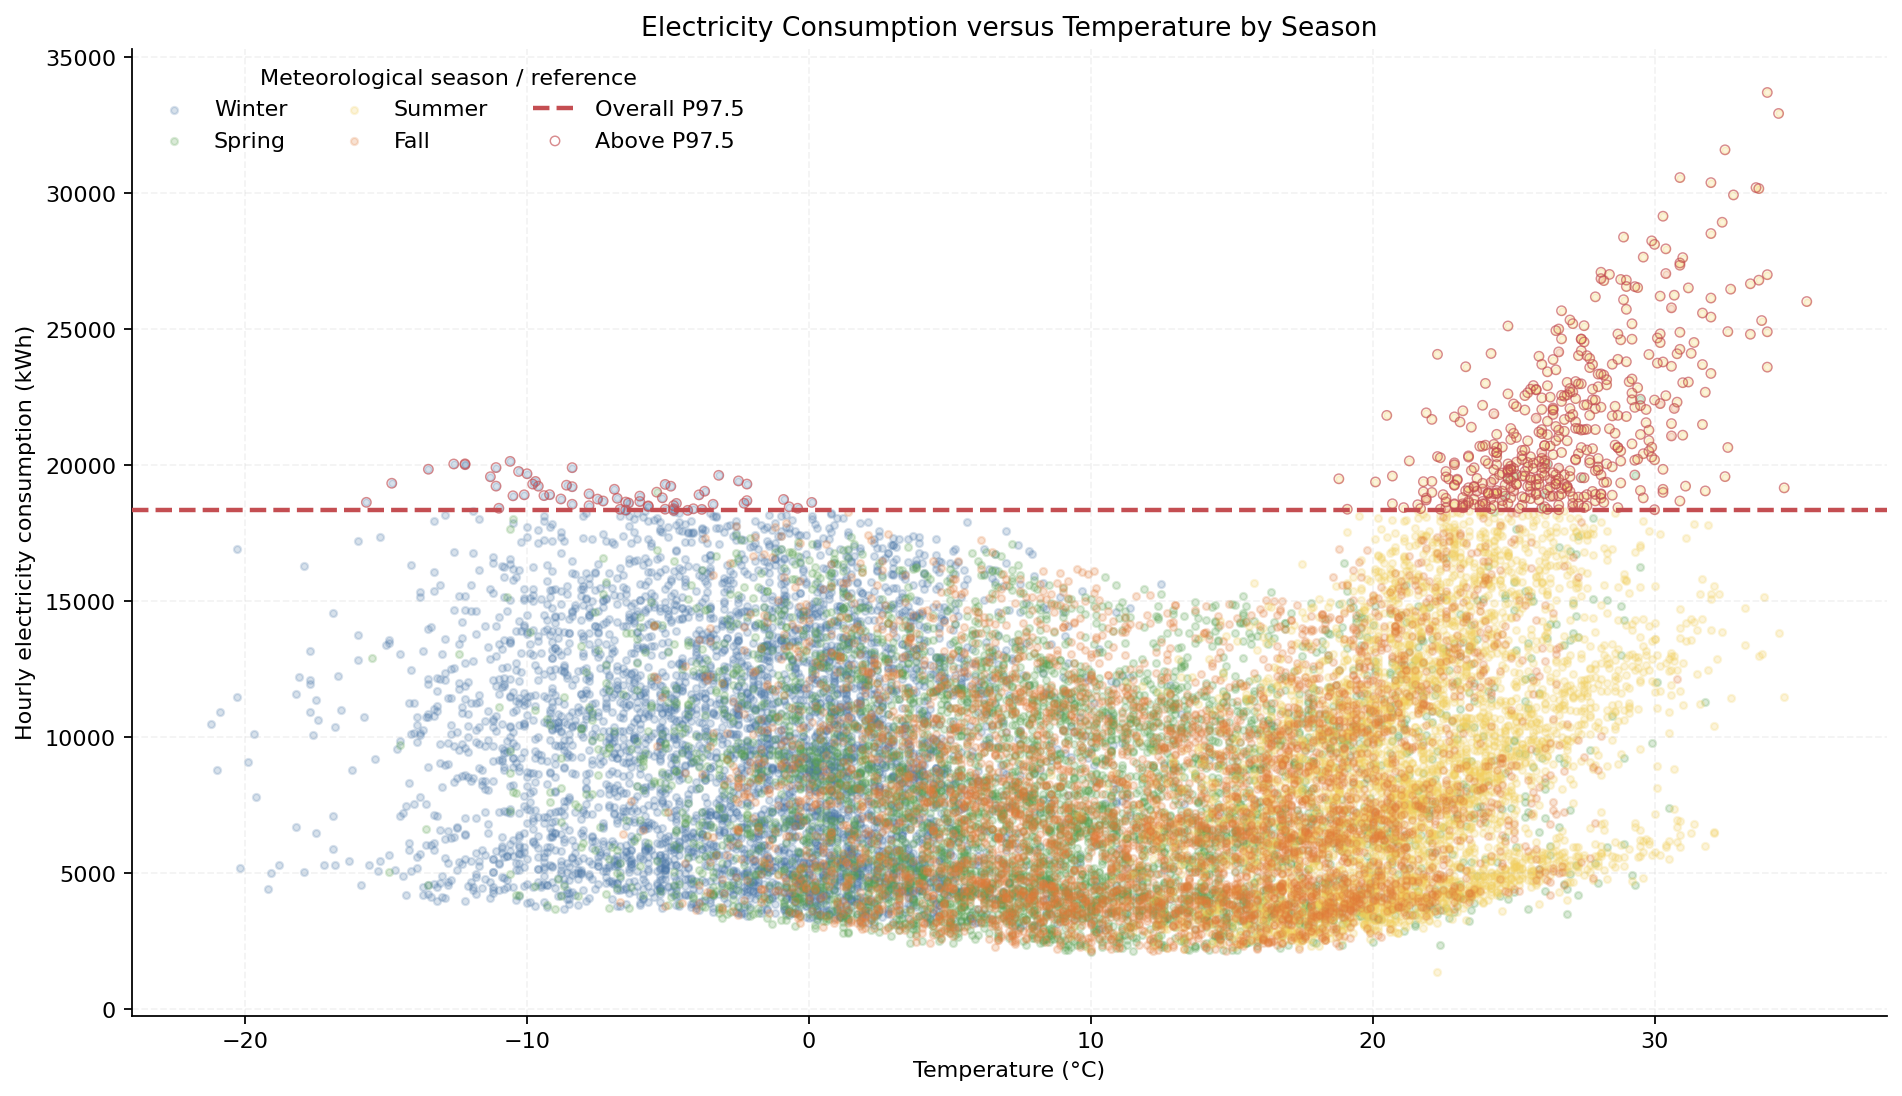


05_04_consumption_vs_temperature_enhanced_v2.png


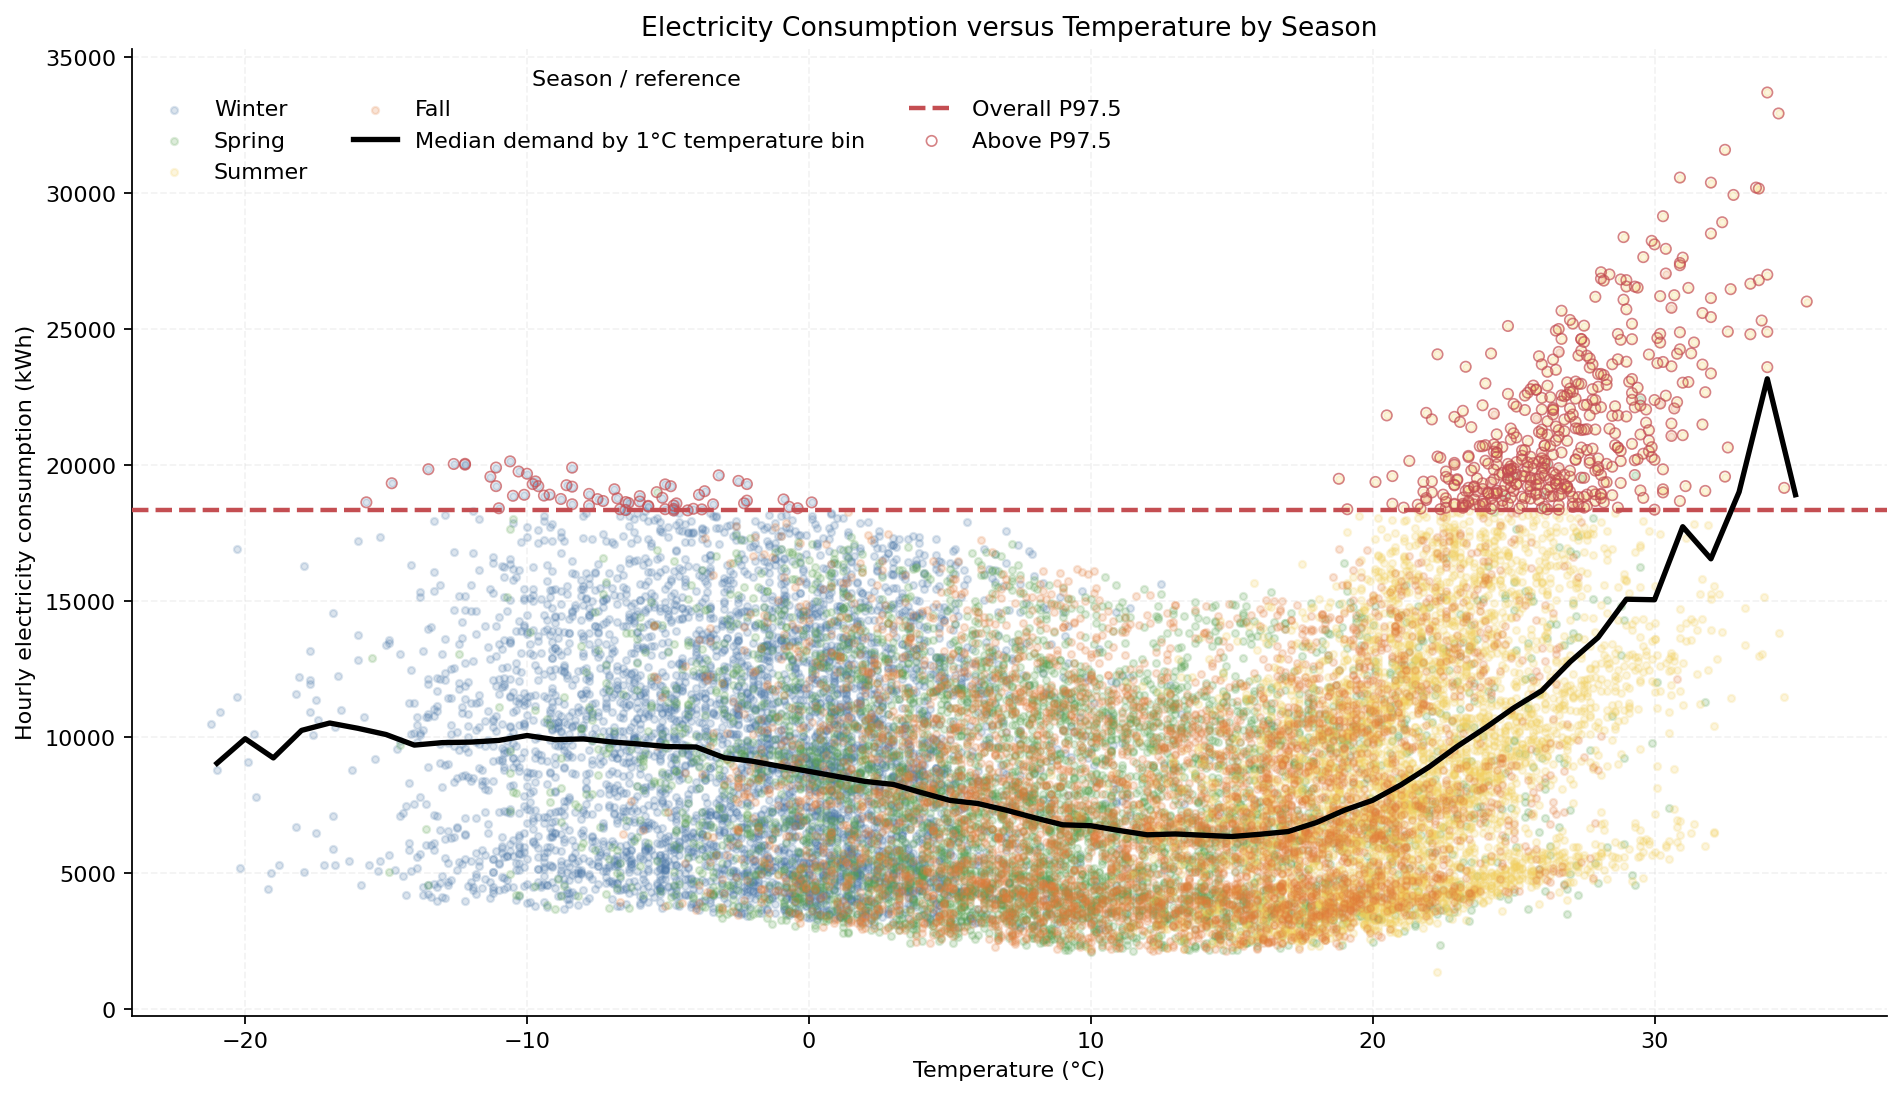


05_04_weather_correlation_matrix.png


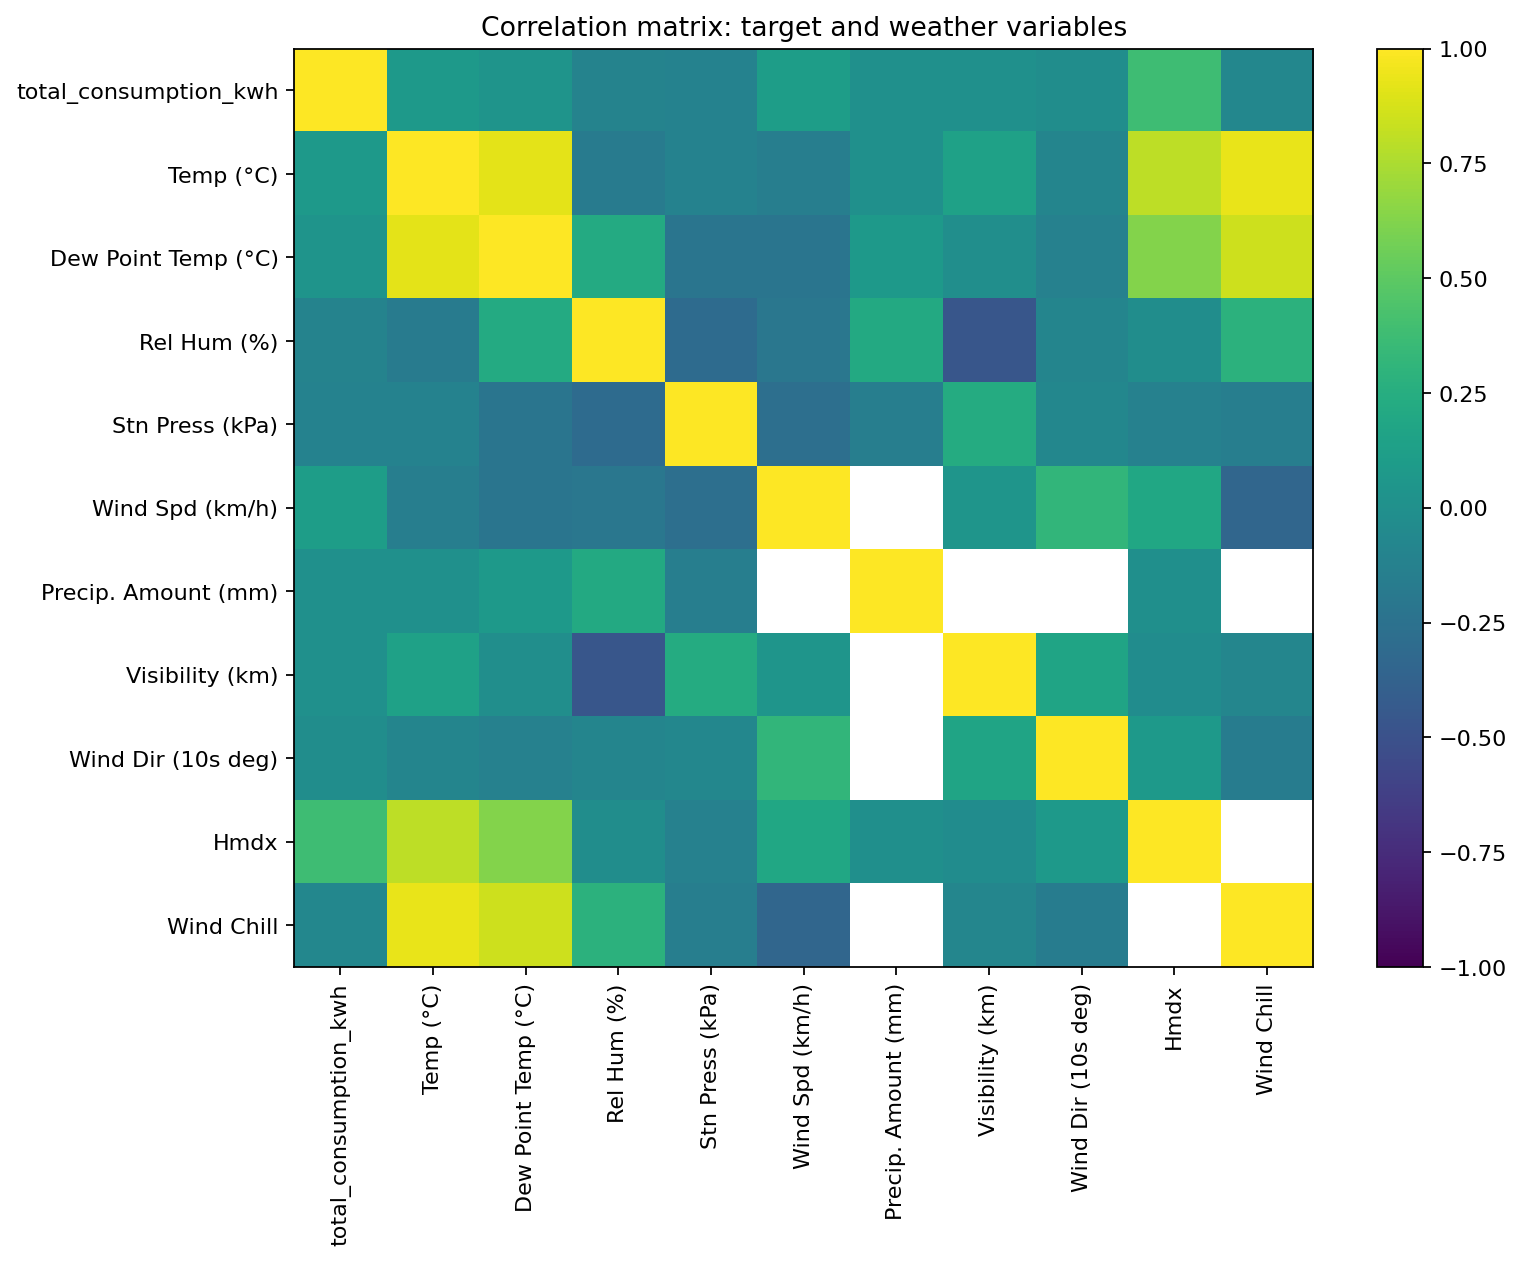


05_04_weather_coverage_by_station.png


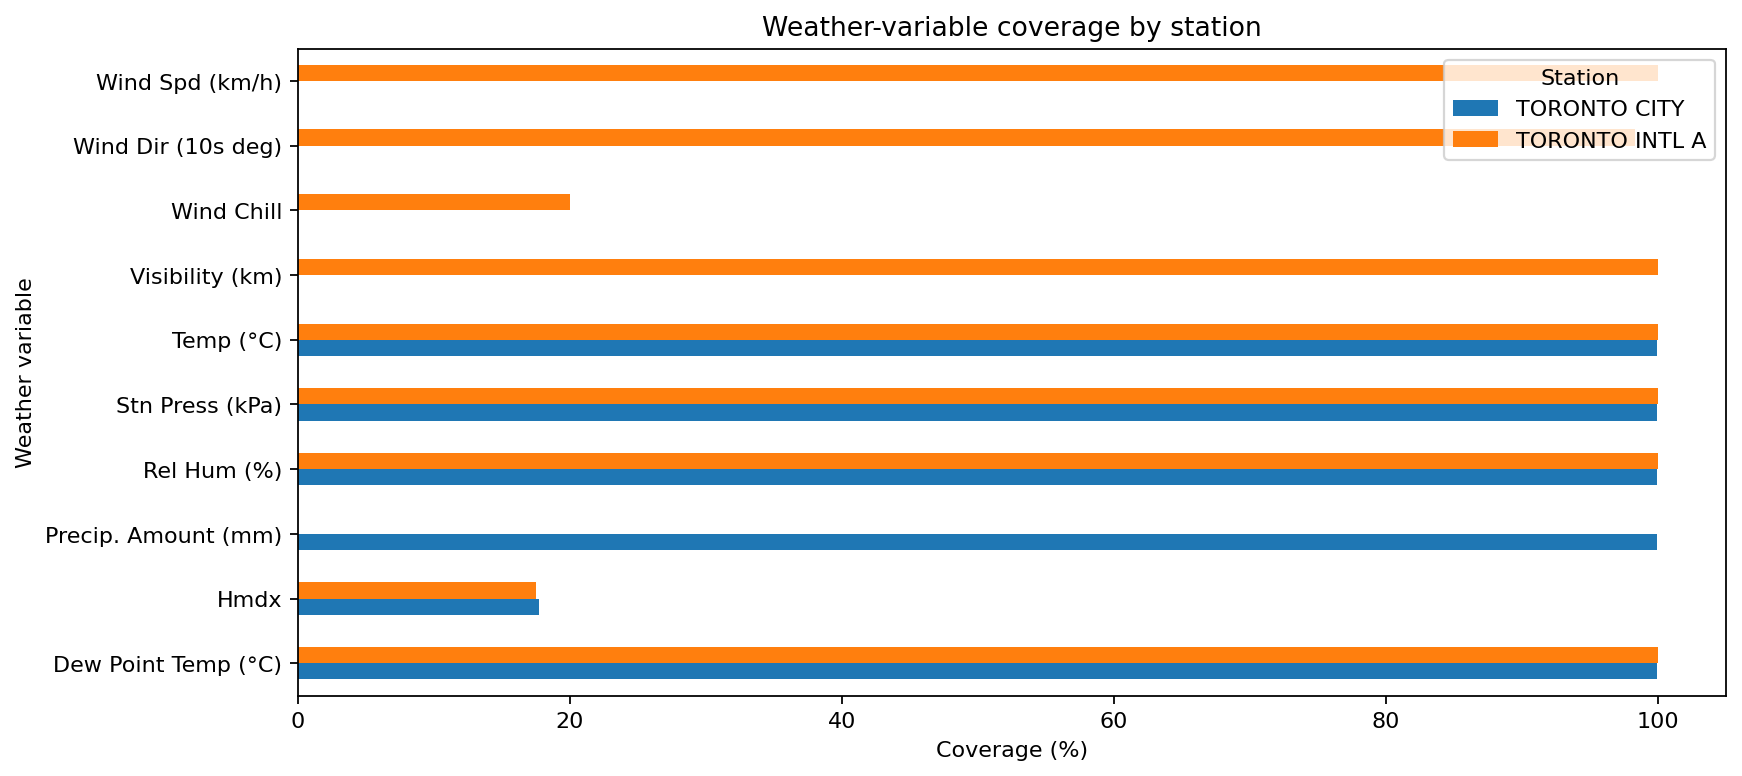


05_04_weather_coverage_heatmap.png


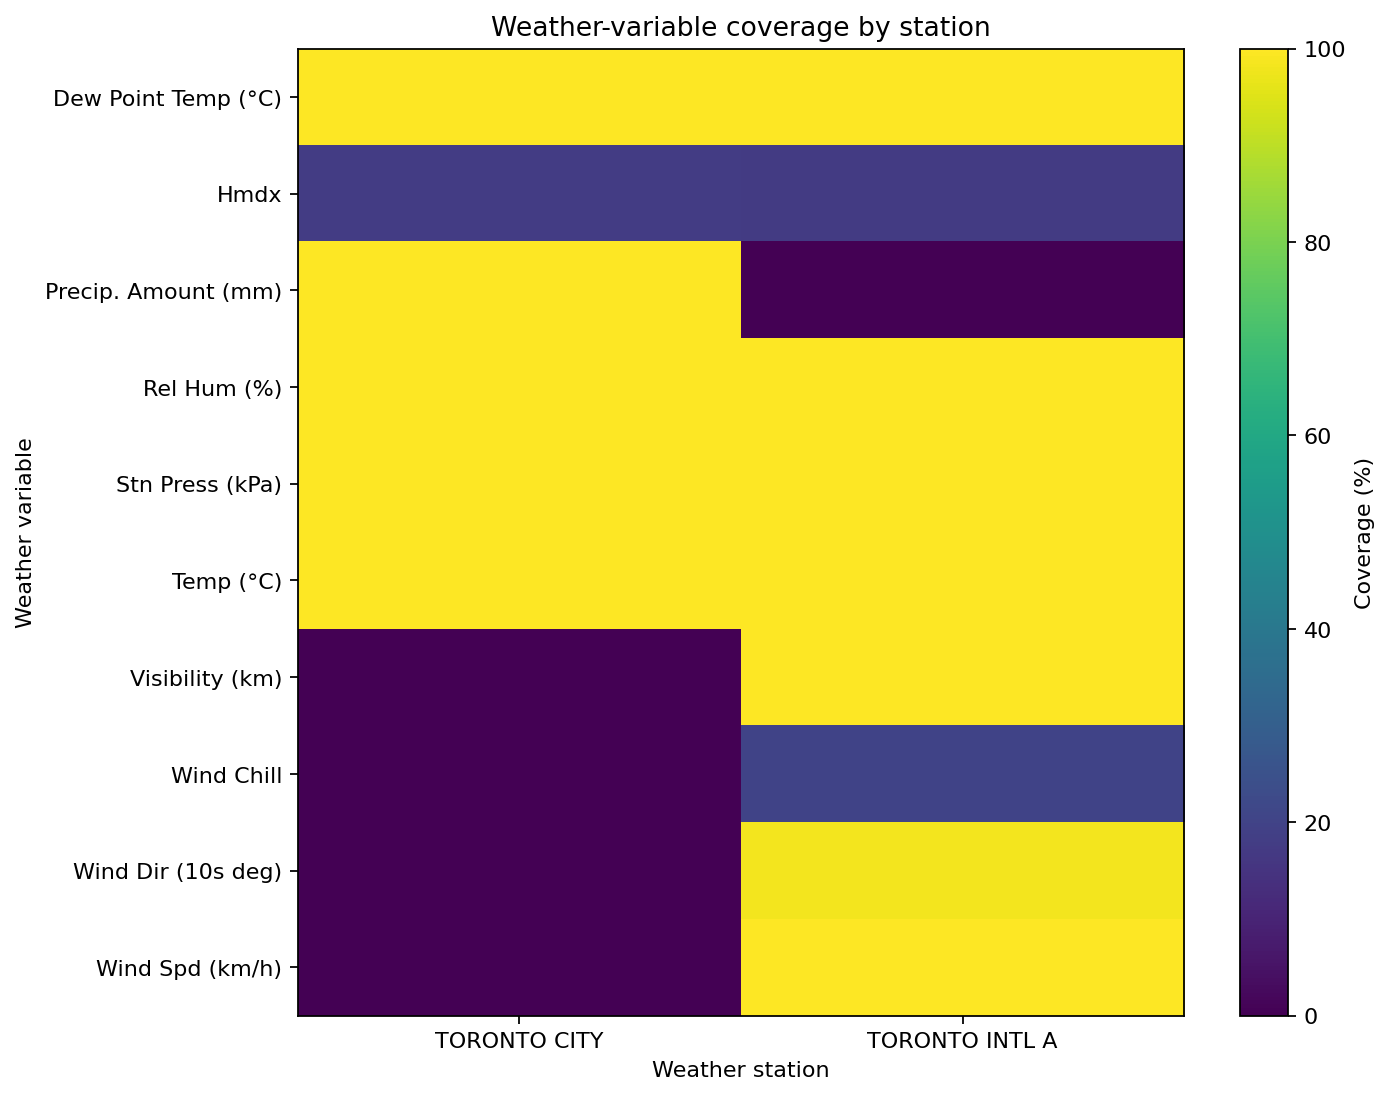

In [16]:
# Display all figures generated by the 05.04 analysis
generated_figures = sorted(
    FIGURES_DIR.glob("05_04_*.png")
)

print(
    f"Generated figures: {len(generated_figures)}"
)

for figure_path in generated_figures:
    print(f"\n{figure_path.name}")
    display(
        Image(
            filename=str(figure_path)
        )
    )